## setup_constants

In [2]:
import numpy as np
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

## Column definitions 


#### Dataset `df_soc` (hourly simulation data)

| Column name           | Unit | Description |
|-----------------------|------|-------------|
| `hour_index`          | —    | Sequential hour index starting at 0 (0–8759) |
| `Month`               | —    | Calendar month (1–12) from source data |
| `Day`                 | —    | Calendar day (1–31) from source data |
| `Hour`                | —    | Hour of day (0–23) from source data |
| `panel_area_m2`       | m²   | Effective area of the PV panel for this record |
| `Gh_W_m2`             | W/m² | Global horizontal irradiance from input dataset |
| `Tamb_C`              | °C   | Ambient air temperature from input dataset |
| `Tmod_C`              | °C   | Estimated PV cell temperature based on NOCT model |
| `eta_pv`              | —    | Temperature-corrected PV efficiency |
| `Ppv_W`               | W    | Instantaneous PV power output for this hour |
| `Ppmu_W`              | W    | Power available after PMU efficiency losses |
| `E_net_Wh`            | Wh   | Hourly net energy balance (generation – consumption) |
| `battery_capacity_Wh` | Wh   | Nominal capacity of the battery being simulated |
| `SoC`                 | —    | Simulated state of charge (0–1) after each hour |

#### Dataset `summary` (annual performance per configuration)

| Column name            | Unit | Description |
|------------------------|------|-------------|
| `panel_area_m2`        | m²   | Effective area of the PV panel |
| `battery_capacity_Wh`  | Wh   | Nominal capacity of the battery |
| `hours_total`          | h    | Total number of simulated hours (normally 8760) |
| `hours_soc_min`        | h    | Number of hours with SoC at or below SOC_MIN |
| `hours_soc_full`       | h    | Number of hours with SoC at full capacity (1.0) |
| `soc_mean`             | —    | Mean state of charge over the year |
| `soc_std`              | —    | Standard deviation of SoC over the year |
| `energy_surplus_Wh`    | Wh   | Total annual surplus energy (positive E_net) |
| `energy_deficit_Wh`    | Wh   | Total annual energy deficit (negative E_net) |
| `soc_min_fraction`     | —    | Fraction of time at minimum SoC |
| `soc_full_fraction`    | —    | Fraction of time at full SoC |
| `energy_balance_Wh`    | Wh   | Net annual energy balance (surplus − deficit) |
| `autonomy_hours`  | h    | Maximum continuous duration the system remains above SOC_MIN before depleting the battery |

In [3]:
# --- Node parameters ---
NODE_POWER_W = 0.05  # Constant node power consumption (50 mW)

# --- Photovoltaic panel constants ---
ETA_STC = 0.175        # Efficiency at STC
GAMMA_PER_C = -0.0045  # Temperature coefficient (%/°C)
NOCT_C = 45.0          # Nominal Operating Cell Temperature (°C)

# --- PMU constants ---
PMU_ETA = 0.90  # PMU global efficiency

# --- Battery constants ---
BATTERY_ETA_C = 0.95  # Charge/discharge efficiency
SOC_MIN = 0.2         # Minimum allowed SoC (fraction)

# --- Variable parameter ranges ---

# Photovoltaic panel areas (1–400 cm²)
panel_areas_m2 = [
    0.0001,   # 1 cm²
    0.00025,  # 2.5 cm²
    0.0004,   # 4 cm²
    0.000625, # 6.25 cm² (≈2.5×2.5 cm)
    0.0010,   # 10 cm²
    0.0025,   # 25 cm²
    0.0040,   # 40 cm²
    0.00625,  # 62.5 cm² (≈8×8 cm cell)
    0.0080,   # 80 cm²
    0.0100,   # 100 cm² (≈10×10 cm)
    0.0160,   # 160 cm² (≈12.6×12.6 cm)
    0.0250,   # 250 cm² (≈15.8×15.8 cm)
    0.0310,   # 310 cm² (≈17.6×17.6 cm)
    0.0400    # 400 cm² (≈20×20 cm)
]

# Battery capacities (realistic values for IoT applications)
battery_capacities_Wh = [
    0.1,   # small Li-ion coin cell (~30 mAh @ 3.7 V)
    0.25,  # supercap or small LiPo
    0.5,   # compact LiPo (~135 mAh @ 3.7 V)
    1.0,   # small pouch cell (~270 mAh @ 3.7 V)
    2.0,   # standard Li-ion (~500–600 mAh)
    3.7,   # one 18650 cell (~1000 mAh @ 3.7 V)
    5.0,   # slightly larger LiPo pack
    7.4,   # two 18650 in series (~2000 mAh total @ 3.7 V)
    10.0,  # larger IoT/portable device battery
    15.0,  # compact powerbank or multi-cell pack
    20.0   # large IoT node with multi-day autonomy
]

## build_design_space

In [4]:
# --- Generate design space: combinations of variable parameters ---
design_space = list(itertools.product(
    panel_areas_m2,
    battery_capacities_Wh,
    [PMU_ETA]
))

# --- Convert combinations into a DataFrame ---
df_design = pd.DataFrame(design_space, columns=[
    "panel_area_m2",
    "battery_capacity_Wh",
    "pmu_eta"
])

# --- Preview ---
df_design

,panel_area_m2,battery_capacity_Wh,pmu_eta
0,0.0001,0.10,0.9
1,0.0001,0.25,0.9
2,0.0001,0.50,0.9
3,0.0001,1.00,0.9
4,0.0001,2.00,0.9
...,...,...,...
149,0.0400,5.00,0.9
150,0.0400,7.40,0.9
151,0.0400,10.00,0.9
152,0.0400,15.00,0.9


## load_irradiance_data

In [5]:
# --- Load irradiance and temperature data ---
irr_data = pd.read_csv("irradiance.csv")

# --- Basic sanity checks ---
expected_cols = ["Date-hour", "Month", "Day", "Hour", "G(h)", "Temperature"]
missing_cols = [c for c in expected_cols if c not in irr_data.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

# --- Rename columns for internal consistency ---
irr_data = irr_data.rename(columns={
    "Date-hour": "datetime_str",
    "G(h)": "Gh_W_m2",
    "Temperature": "Tamb_C"
})

# --- Keep only relevant numeric columns ---
irr_data = irr_data[["Month", "Day", "Hour", "Gh_W_m2", "Tamb_C"]].reset_index(drop=True)

# --- Preview ---
irr_data.head()

,Month,Day,Hour,Gh_W_m2,Tamb_C
0,1,1,5,0,2.81
1,1,1,6,0,2.28
2,1,1,7,0,1.74
3,1,1,8,61,2.17
4,1,1,9,222,2.45


## compute_pv_power

In [6]:
# --- Build a long-format DataFrame: one row per hour and panel area ---

# Duplicate irradiance data for each panel area
df_pv = pd.concat(
    [irr_data.assign(panel_area_m2=A) for A in panel_areas_m2],
    ignore_index=True
)

# Compute module temperature based on NOCT model
df_pv["Tmod_C"] = df_pv["Tamb_C"] + (NOCT_C - 20.0) / 800.0 * df_pv["Gh_W_m2"]

# Compute temperature-corrected panel efficiency
df_pv["eta_pv"] = ETA_STC * (1.0 + GAMMA_PER_C * (df_pv["Tmod_C"] - 25.0))

# Compute PV power output
df_pv["Ppv_W"] = df_pv["Gh_W_m2"] * df_pv["panel_area_m2"] * df_pv["eta_pv"]

# Add hour index (0..n-1)
df_pv["hour_index"] = df_pv.groupby("panel_area_m2").cumcount()

# Keep relevant columns
df_pv = df_pv[[
    "hour_index",
    "Month",
    "Day",
    "Hour",
    "panel_area_m2",
    "Gh_W_m2",
    "Tamb_C",
    "Tmod_C",
    "eta_pv",
    "Ppv_W"
]]

# --- Preview ---
df_pv.head()

,hour_index,Month,Day,Hour,panel_area_m2,Gh_W_m2,Tamb_C,Tmod_C,eta_pv,Ppv_W
0,0,1,1,5,0.0001,0,2.81,2.81000,0.192475,0.000000
1,1,1,1,6,0.0001,0,2.28,2.28000,0.192892,0.000000
2,2,1,1,7,0.0001,0,1.74,1.74000,0.193317,0.000000
3,3,1,1,8,0.0001,61,2.17,4.07625,0.191477,0.001168
4,4,1,1,9,0.0001,222,2.45,9.38750,0.187295,0.004158


## compute_hourly_balance

In [7]:
# --- Compute power after PMU efficiency ---
df_pv["Ppmu_W"] = df_pv["Ppv_W"] * PMU_ETA

# --- Compute hourly net energy balance ---
# E_net = (Ppmu - NODE_POWER_W) * 1 hour  -> Wh
df_pv["E_net_Wh"] = (df_pv["Ppmu_W"] - NODE_POWER_W)

# --- Preview ---
df_pv.head()

,hour_index,Month,Day,Hour,panel_area_m2,Gh_W_m2,Tamb_C,Tmod_C,eta_pv,Ppv_W,Ppmu_W,E_net_Wh
0,0,1,1,5,0.0001,0,2.81,2.81000,0.192475,0.000000,0.000000,-0.050000
1,1,1,1,6,0.0001,0,2.28,2.28000,0.192892,0.000000,0.000000,-0.050000
2,2,1,1,7,0.0001,0,1.74,1.74000,0.193317,0.000000,0.000000,-0.050000
3,3,1,1,8,0.0001,61,2.17,4.07625,0.191477,0.001168,0.001051,-0.048949
4,4,1,1,9,0.0001,222,2.45,9.38750,0.187295,0.004158,0.003742,-0.046258


## simulate_battery_soc

In [8]:
# --- Build battery simulation dataset (one row per hour, panel, and battery) ---

# Duplicate PV data for each battery capacity
df_soc = pd.concat(
    [df_pv.assign(battery_capacity_Wh=Cbat) for Cbat in battery_capacities_Wh],
    ignore_index=True
)

# Prepare SoC column
df_soc["SoC"] = np.nan

# Iterate over each combination of (panel_area_m2, battery_capacity_Wh)
for (A, Cbat), group_idx in df_soc.groupby(["panel_area_m2", "battery_capacity_Wh"]).groups.items():
    idx = list(group_idx)
    e_net = df_soc.loc[idx, "E_net_Wh"].to_numpy()

    soc = np.empty_like(e_net)
    soc[0] = 1.0  # start fully charged

    for i in range(1, len(e_net)):
        delta = e_net[i]
        if delta >= 0:
            soc[i] = soc[i - 1] + (delta / Cbat) * BATTERY_ETA_C
        else:
            soc[i] = soc[i - 1] + (delta / Cbat) / BATTERY_ETA_C

        # clamp to [SOC_MIN, 1.0]
        if soc[i] > 1.0:
            soc[i] = 1.0
        elif soc[i] < SOC_MIN:
            soc[i] = SOC_MIN

    df_soc.loc[idx, "SoC"] = soc

# --- Preview ---
df_soc.head()

,hour_index,Month,Day,Hour,panel_area_m2,Gh_W_m2,Tamb_C,Tmod_C,eta_pv,Ppv_W,Ppmu_W,E_net_Wh,battery_capacity_Wh,SoC
0,0,1,1,5,0.0001,0,2.81,2.81000,0.192475,0.000000,0.000000,-0.050000,0.1,1.000000
1,1,1,1,6,0.0001,0,2.28,2.28000,0.192892,0.000000,0.000000,-0.050000,0.1,0.473684
2,2,1,1,7,0.0001,0,1.74,1.74000,0.193317,0.000000,0.000000,-0.050000,0.1,0.200000
3,3,1,1,8,0.0001,61,2.17,4.07625,0.191477,0.001168,0.001051,-0.048949,0.1,0.200000
4,4,1,1,9,0.0001,222,2.45,9.38750,0.187295,0.004158,0.003742,-0.046258,0.1,0.200000


## evaluate_viability

In [9]:
# --- Evaluate annual performance and viability of each configuration ---

def longest_autonomy_hours(soc_series: np.ndarray, soc_min: float) -> int:
    """Return the longest continuous period (in hours) that SoC stays above soc_min."""
    below = soc_series <= soc_min + 1e-6
    if np.all(below):
        return 0
    # Compute lengths of sequences above SOC_MIN
    max_len = 0
    current = 0
    for v in below:
        if not v:
            current += 1
            max_len = max(max_len, current)
        else:
            current = 0
    return max_len

summary = (
    df_soc
    .groupby(["panel_area_m2", "battery_capacity_Wh"], as_index=False)
    .agg(
        hours_total=("SoC", "count"),
        hours_soc_min=("SoC", lambda s: np.sum(s <= SOC_MIN + 1e-6)),
        hours_soc_full=("SoC", lambda s: np.sum(s >= 1.0 - 1e-6)),
        soc_mean=("SoC", "mean"),
        soc_std=("SoC", "std"),
        energy_surplus_Wh=("E_net_Wh", lambda s: np.sum(np.clip(s, 0, None))),
        energy_deficit_Wh=("E_net_Wh", lambda s: -np.sum(np.clip(s, None, 0))),
        autonomy_hours=("SoC", lambda s: longest_autonomy_hours(s.to_numpy(), SOC_MIN))
    )
)

# Compute derived metrics
summary["soc_min_fraction"] = summary["hours_soc_min"] / summary["hours_total"]
summary["soc_full_fraction"] = summary["hours_soc_full"] / summary["hours_total"]
summary["energy_balance_Wh"] = summary["energy_surplus_Wh"] - summary["energy_deficit_Wh"]

# --- Preview ---
summary.head()


,panel_area_m2,battery_capacity_Wh,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,energy_surplus_Wh,energy_deficit_Wh,autonomy_hours,soc_min_fraction,soc_full_fraction,energy_balance_Wh
0,0.0001,0.10,5475,5473,1,0.200196,0.011426,0.0,249.941934,2,0.999635,0.000183,-249.941934
1,0.0001,0.25,5475,5471,1,0.200355,0.014559,0.0,249.941934,4,0.999269,0.000183,-249.941934
2,0.0001,0.50,5475,5466,1,0.200653,0.019095,0.0,249.941934,9,0.998356,0.000183,-249.941934
3,0.0001,1.00,5475,5459,1,0.201241,0.026066,0.0,249.941934,16,0.997078,0.000183,-249.941934
4,0.0001,2.00,5475,5443,1,0.202407,0.036011,0.0,249.941934,32,0.994155,0.000183,-249.941934


## plot_viability_maps

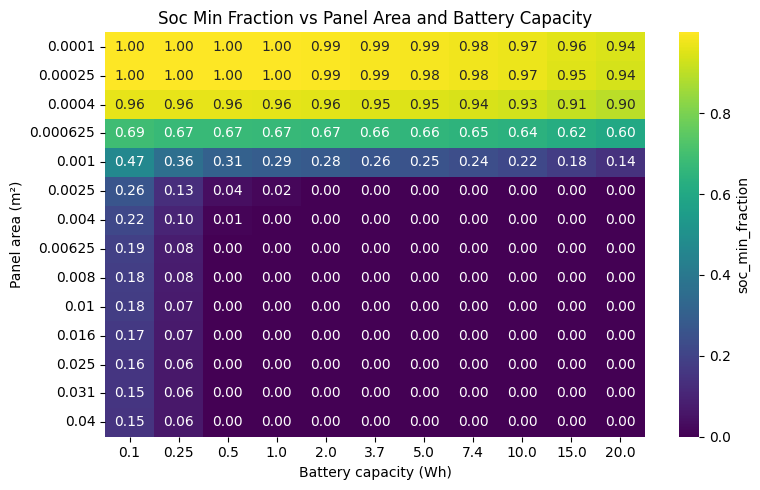

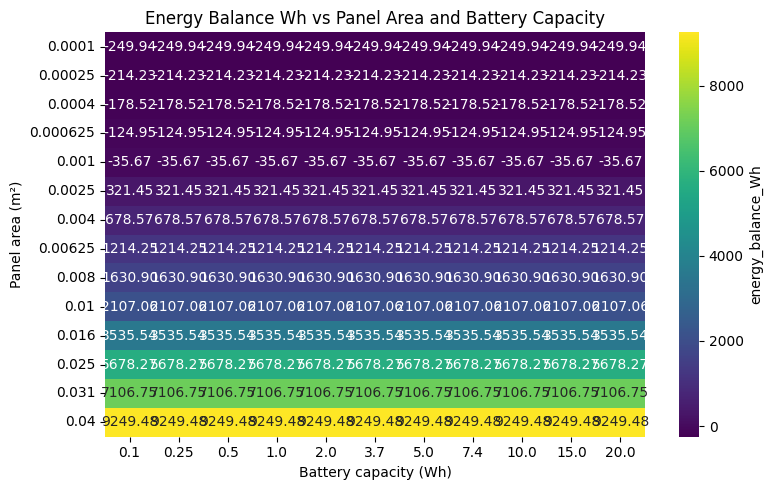

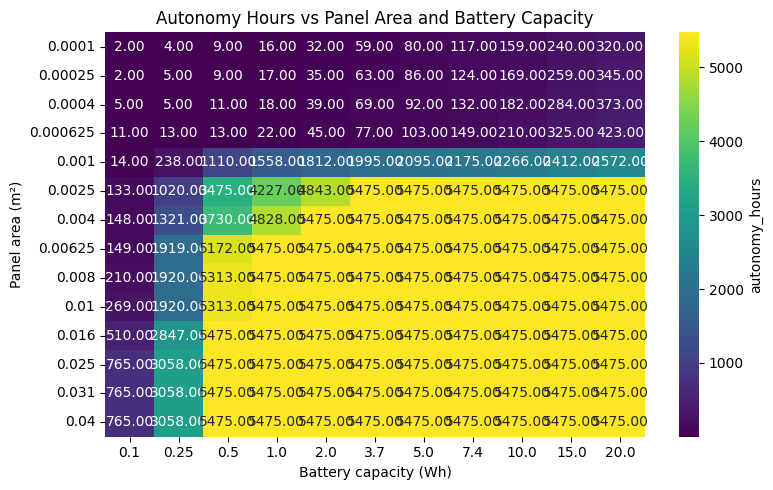

In [10]:
# seaborn heatmaps for key viability metrics

metrics = ["soc_min_fraction", "energy_balance_Wh", "autonomy_hours"]

for metric in metrics:
    pivot = summary.pivot(index="panel_area_m2", columns="battery_capacity_Wh", values=metric)

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar_kws={"label": metric}
    )
    plt.title(f"{metric.replace('_', ' ').title()} vs Panel Area and Battery Capacity")
    plt.xlabel("Battery capacity (Wh)")
    plt.ylabel("Panel area (m²)")
    plt.tight_layout()
    plt.show()
